# 報酬與風險
---

* 在金融市場中，報酬與風險總是存在著取捨關係。一般而言，人們認為承擔的風險越高，則相對的預期報酬越高。
* Markowitz (1952) 提出了效率前緣 (efficient frontier)，透過數學與統計的方式刻劃了報酬與風險之間的關係。
* 在他的研究中，一個投資組合的報酬 ($E[R_p]$) 與其風險 ($\sigma_p$) 的定義如下：$$E[R_p] = \sum_{i=1}^n w_i E[R_i],$$ 以及 $$\sigma_p = \sqrt{\sum_{i=1}^n \sum_{j=1}^n w_i w_j Cov(i, j)},$$ 其中 $R_p$ 為投資組合的報酬率、$w_i$ 為第 $i$ 項資產在投資組合中所佔的權重 (權重和必需為 1)、$E[R_i]$ 為第 $i$ 項資產的報酬率，以及$Cov(i, j)$ 為資產 $i$ 與資產 $j$ 的共變異數。
* 以下透過程式模擬來視覺化呈現 Markowitz 的效率前緣。

In [1]:
# Import packages

import statsmodels.api as sm
import numpy as np
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import warnings

In [2]:
warnings.filterwarnings("ignore")
np.random.seed(123)

In [3]:
# Basic settings

n_assets = 10
n_periods = 2520
n_portfolio = 2000

# Simulate the expected return and the standard deviation for assets
mu_true = np.random.uniform(0.02, 0.25, n_assets)
A = np.random.randn(n_assets, n_assets)
cov_true = A @ A.T / n_assets

returns = np.random.multivariate_normal(mu_true, cov_true, size=n_periods)
mu = returns.mean(axis=0)
Sigma = np.cov(returns.T, ddof=1)

In [4]:
# Calculate returns and standard deviation for the portfolio

def port_return(mu, Sigma, weights):
    portfolio_return = weights @ mu
    portfolio_std = np.sqrt(weights @ Sigma @ weights)

    return portfolio_return, portfolio_std

In [5]:
portfolio = np.array([
    port_return(mu, Sigma, np.random.dirichlet(np.ones(n_assets)))
    for _ in range(n_portfolio)
])

In [6]:
from scipy.optimize import minimize

# Construct the efficient frontier
def efficient_frontier(mu, Sigma, r_grid, n_assets):
    def objective(w):
        return w @ Sigma @ w

    def solve(target_return):
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w: w @ mu - target_return},
        ]
        bounds = [(0, 1)] * n_assets
        w0 = np.ones(n_assets) / n_assets
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return np.sqrt(result.fun) if result.success else np.nan

    return np.array([solve(r) for r in r_grid])

In [7]:
r_grid = np.linspace(mu.min() + 0.005, mu.max() - 0.005, 100)
frontier_std = efficient_frontier(mu, Sigma, r_grid, n_assets)

## 視覺化結果解讀
1. 在最後的圖中，X 軸為風險，、Y 軸為報酬、以及圖上的藍點為投資組合，所以這張圖說明的是「對於某個權重下的投資組合，它所承受的風險以及報酬是多少」。
2. 將最外圍的投資組合連線起來，就能夠造出效率前緣，可以看到這是一條雙曲線。這條線要說明的是「沿著這條線往右移動時，斜率代表多一單位風險能換到多少額外報酬」。
3. 值得注意的是，效率前緣的下半部是沒有意義的，因為它代表多承受風險，但報酬卻降低了，所以投資人根本不會考慮這部分的投資組合。

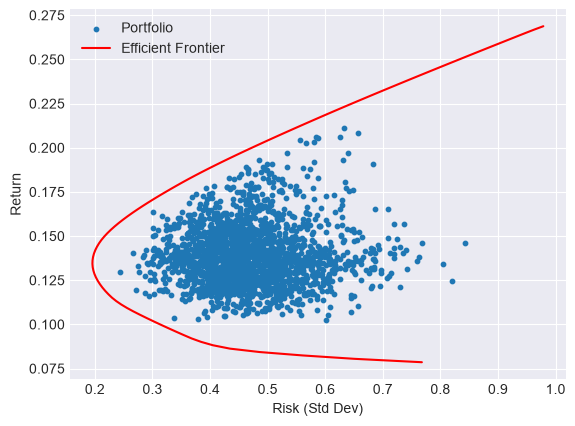

In [8]:
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure()
plt.scatter(portfolio[:, 1], portfolio[:, 0], s=10, label='Portfolio')
plt.plot(frontier_std, r_grid, color='red', label='Efficient Frontier')
plt.xlabel('Risk (Std Dev)')
plt.ylabel('Return')
plt.legend()
plt.show()

# 風險管理與主要金融風險
---

## 風險管理
* 「金融風險管理」顧名思義便是處理金融市場中存在的不確定性，而這些不確定性會被視為是風險。
* 從上一節中我們已經知道風險與報酬的取捨關係，因此風險管理並非是一昧地將風險完全消除，而是在保持獲利的狀態下，盡可能降低風險到可以掌控的範圍內，即便這會犧牲獲利。
* 一般而言，金融風險管理有四種決策：忽視 (ignore)、轉移 (transfer)、緩解 (mitigate)、接受 (accept)。

## 主要金融風險
* 在金融市場中，對於投資人而言最主要的金融風險有以下三種：
    1. 市場風險：市場商品，如利率、匯率，或是商品價格，所帶來的風險。
    2. 信用風險：投資人被迫面對交易對手決定的不確定性風險。
    3. 流動性風險：評估一項資產變現的容易程度。

# 資訊不對稱
---

* 在傳統經濟學或是財務經濟學理論中，我們通常假設人們 / 投資人是理性的。
* 但現實世界中往往不是如此，更多時候會因為交易兩造掌握的資訊程度不同而有不同的行為模式。

## 逆向選擇
* 逆向選擇指的是在交易發生前，買賣雙方因為「資訊不對稱」，導致市場上品質好的商品或低風險的參與者被淘汰，最後只剩下劣質品或高風險參與者的現象。
* 以下透過保險費用的例子來說明，情境如下：
  - 市場上有一群人，每個人都面臨生病的風險，也就是有可能「以機率 $\pi$ 損失金額 $c$」。
  - 每個人生病的風險都不一樣，然而保險公司看不出誰是高風險的人、誰是低風險的人，只能對所有來買保險的人收同一個保費 $D$。

1. 假設投資人對收入的效用函數為 CARA (Constant Absolute Risk Aversion) 效用函數，$$U(x) = -e^{-\gamma x},$$ 其中 $x$ 為收入，以及 $\gamma$ 為風險趨避係數 (越大代表越害怕風險)。

In [9]:
def utility(x, gamma):
    result = -np.exp(-x * gamma)

    return result

2. 模擬 20 個人，並假設每個人生病的機率獨立服從均勻分佈。模擬完後進行升序排序。

In [10]:
pi = np.random.uniform(0, 1, 20)
pi = np.sort(pi)

3. 設定市場中每個人初期財富 ($y$) 為 2 元、生病後的損失金額 ($c$) 為 1.5 元，以及風險趨避係數 ($\gamma$) 為 0.4。

In [11]:
y = 2
c = 1.5
gamma = 0.4

4. 定義需求函數：對每個人比較兩個選項的效用
   * 買保險：付出保費 ($D$)，財富變成 ($y - D$)，效用是 ($U(y - D)$)，沒有風險 (因為將損失轉移給保險公司)。
   * 不買保險：沒有付出保費，財富有 $\pi$ 的機率變成 $y - c$、有 $1 - \pi$ 的機率維持 $y$、期望效用是 ($\pi \times U(y - c) + (1 - \pi) \times U(y)$)。

   只要 買保險的效用 > 不買保險的效用，這個人就會選擇買保險。

   值得注意的是，因為效用函數是凹性的，$\pi$ 越高的人，其不買保險的效用會被拉低，所以越傾向購買保險。也就是說，高風險的人更想買保險。

In [12]:
def demand(D):
    result = np.sum(
        utility(y - D, gamma)
        > pi * utility(y - c, gamma) + (1 - pi) * utility(y, gamma)
    )

    return result

5. 定義供給函數：取出風險最高的 $Q$ 個人。
   * 這個函數假設，若市場有 $Q$ 個人投保，則，根據逆向選擇效應，一定是風險最高的那些人。
   * 保險公司為了打平成本，收取的保費至少要等於「這 $Q$ 個人的平均理賠成本」，也就是 $Q$ 個人的平均 $\pi$ 乘上損失金額 $c$。
   * 值得注意的是，若是 $Q$ 越大 (投保人數越多)，因為容納的風險越來越低，所以平均風險 $\pi$ 會降低，因此平均成本也會下降。換言之，一開始只有最高風險的人買，保費必須很貴；如果能吸引更多低風險的人加入，平均成本就能降下來 (這是很經典的逆向選擇結果)。

In [13]:
def supply(Q):
    result = np.mean(pi[-Q:]) * c

    return result

## 視覺化結果解讀
1. 藍線 (需求)：對每一個可能的保費 $D$ (0 到 1.9，間隔 0.02)，算出願意投保的人數。保費越高，願意買的人越少，所以這條線應該是遞減的。
2. 橘線 (供給)：對每一個可能的投保人數 $Q$ (1 到 20)，算出保險公司要收支平衡需要的平均成本。前面提過，人數越多平均風險越低，所以這條線也是遞減的。
3. 兩條線的交點，就是這個逆選擇市場的均衡：在這個保費水準下，願意投保的人數，剛好等於讓保險公司打平所需要服務的人數。
4. 值得注意的是，因為供給曲線和需求曲線都是遞減的，均衡可能不只一個、也可能在某些參數下市場會崩潰。

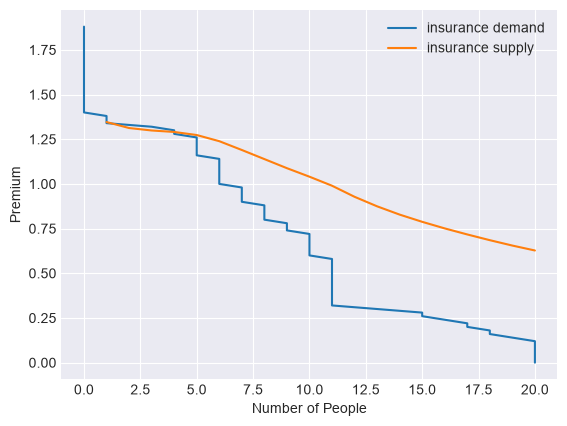

In [14]:
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure()
D_grid = np.arange(0, 1.9, 0.02)
S_grid = range(1, 21)
plt.plot([demand(i) for i in D_grid], D_grid, label="insurance demand")
plt.plot(S_grid, [supply(j) for j in S_grid], label="insurance supply")
plt.ylabel("Premium")
plt.xlabel("Number of People")
plt.legend()
plt.show()

# 參考文獻
Markowitz, H. (1952). Portfolio Selection. *The Journal of Finance*, *7*(1), 77–91. https://doi.org/10.2307/2975974